# Illustration de l'Augmentation de Données avec TensorFlow

Ce notebook montre comment utiliser les couches de prétraitement de TensorFlow pour effectuer de l'augmentation de données en temps réel pendant l'entraînement.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print(f"Version de TensorFlow : {tf.__version__}")

Version de TensorFlow : 2.20.0


In [2]:
# Chargement des données CIFAR-10
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


## Définition de l'Augmentation de Données

Nous utilisons `tf.keras.Sequential` pour regrouper les couches de transformation.

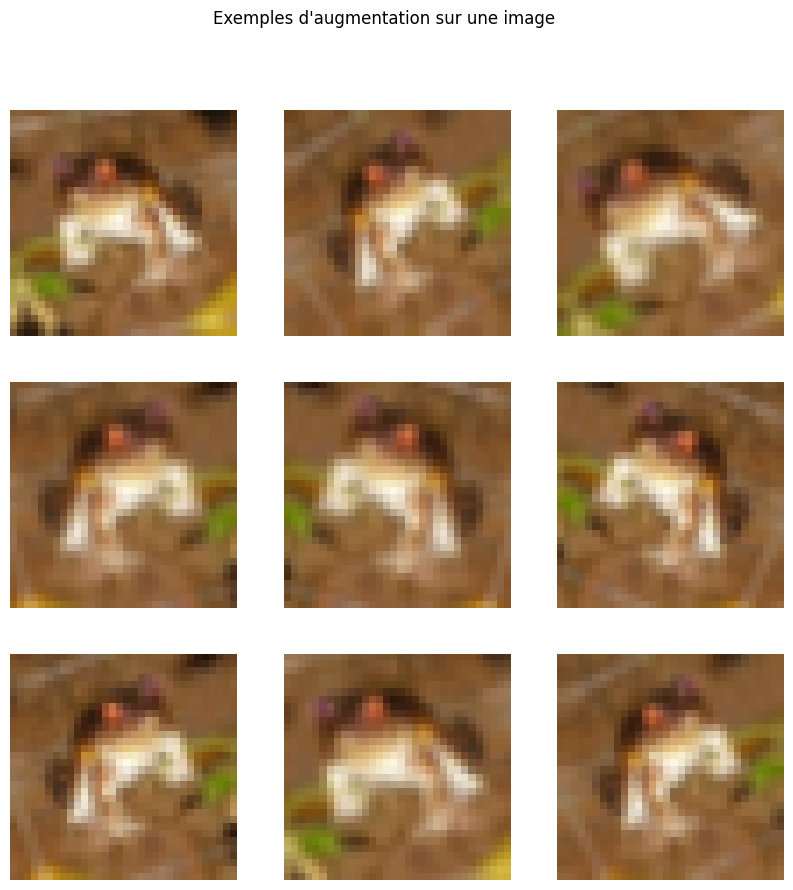

In [3]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# Visualisation d'un exemple
plt.figure(figsize=(10, 10))
for i in range(9):
  augmented_images = data_augmentation(np.expand_dims(train_images[0], 0))
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(augmented_images[0])
  plt.axis("off")
plt.suptitle("Exemples d'augmentation sur une image")
plt.show()

## Entraînement avec et sans Augmentation

In [4]:
def create_model(with_augmentation=False):
    model = models.Sequential()
    if with_augmentation:
        model.add(data_augmentation)

    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Entraînement SANS augmentation...")
model_no_aug = create_model(False)
hist_no_aug = model_no_aug.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels), verbose=0)

print("Entraînement AVEC augmentation...")
model_aug = create_model(True)
hist_aug = model_aug.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels), verbose=0)

Entraînement SANS augmentation...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entraînement AVEC augmentation...


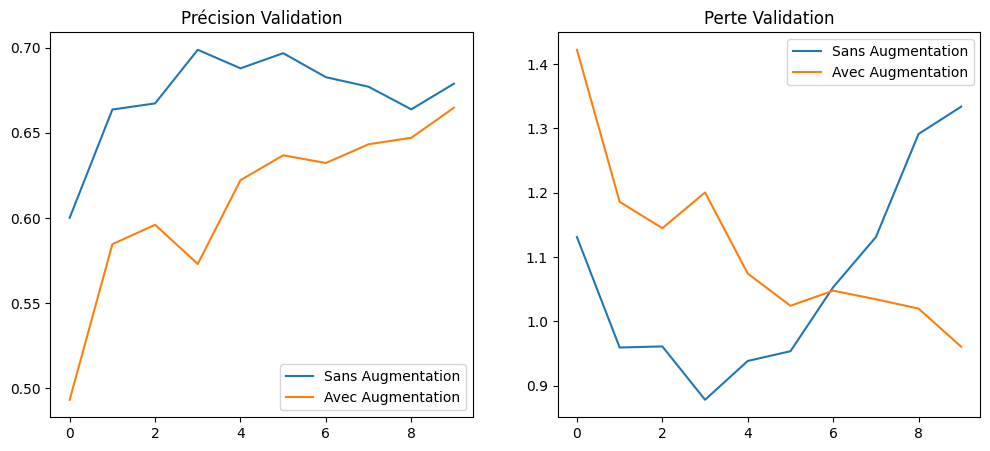

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_no_aug.history['val_accuracy'], label='Sans Augmentation')
plt.plot(hist_aug.history['val_accuracy'], label='Avec Augmentation')
plt.title('Précision Validation')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_no_aug.history['val_loss'], label='Sans Augmentation')
plt.plot(hist_aug.history['val_loss'], label='Avec Augmentation')
plt.title('Perte Validation')
plt.legend()
plt.show()